In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [2]:
fits_files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

headers = []
data_list = []

for file in fits_files:
    with fits.open(file) as hdul:
        headers.append(hdul[0].header)
        data_list.append(hdul[0].data)

print(f"Loaded {len(data_list)} FITS files")
print(f"Each image shape: {data_list[0].shape}")

Loaded 5 FITS files
Each image shape: (1040, 1392)


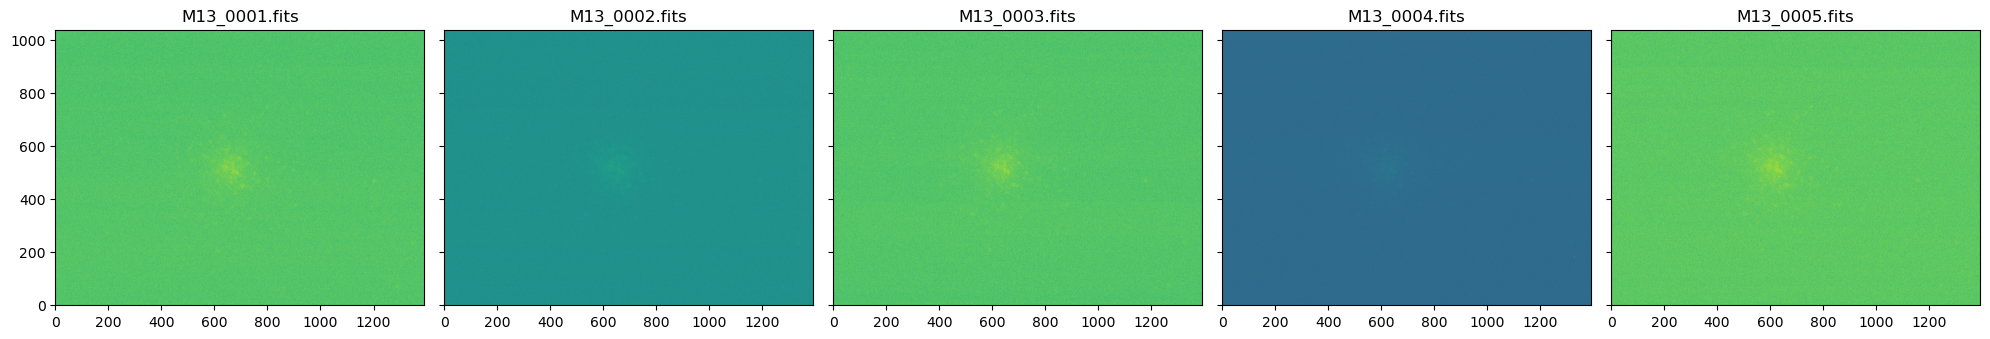

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, (ax, data) in enumerate(zip(axes, data_list)):
    ax.imshow(data, origin="lower")
    ax.set_title(fits_files[i])

plt.tight_layout()
plt.show()

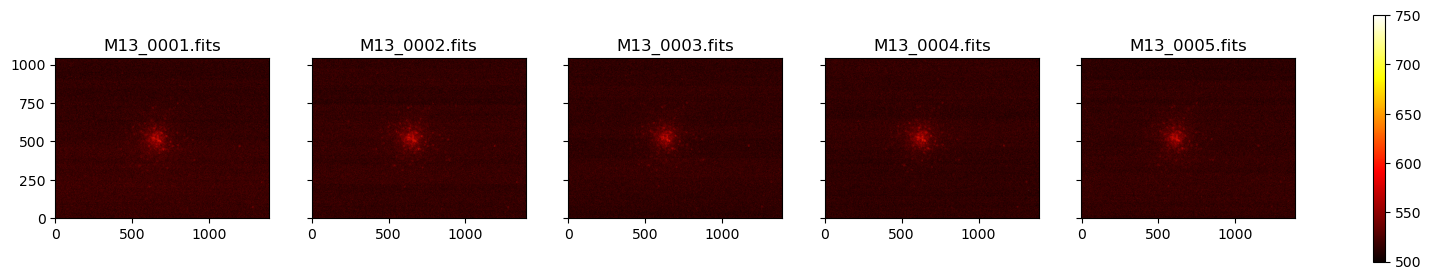

In [53]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, (ax, data) in enumerate(zip(axes, data_list)):
    im = ax.imshow(data, origin="lower",cmap = 'hot', vmin=500,vmax=750)
    ax.set_title(fits_files[i])
   
fig.colorbar(im, ax=axes, shrink=0.8)
#plt.tight_layout()
plt.show()

When you place constraints on pixel brightness and adjust the colormap to accomodate astronomical images, it becomes much easier to see what the image actually contains.

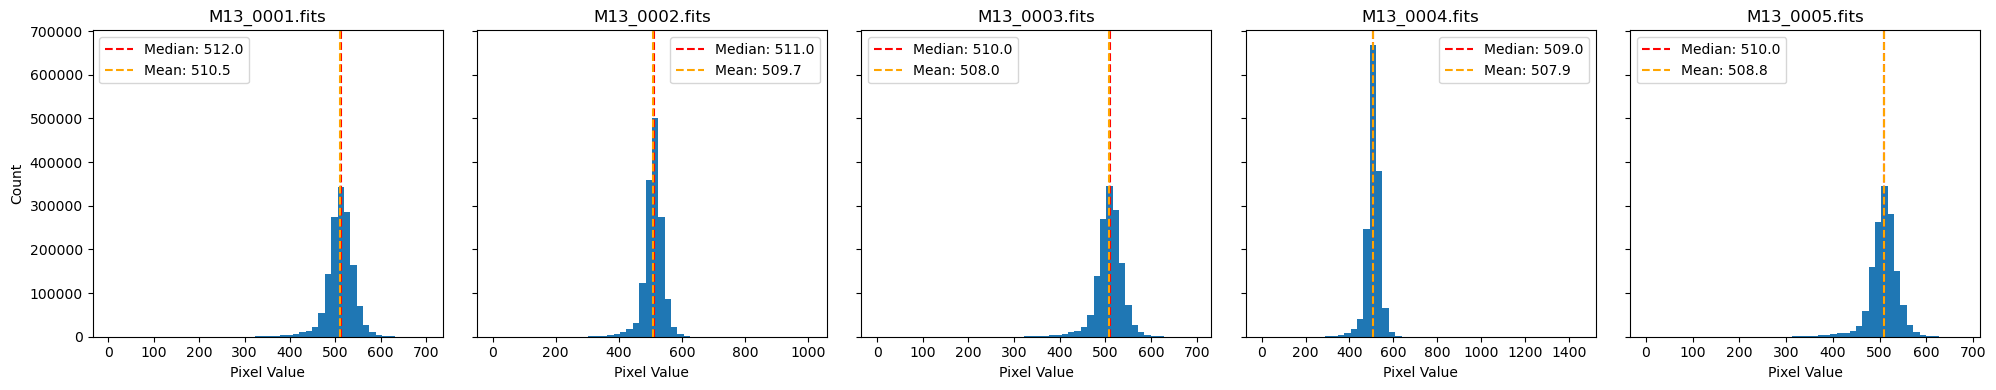

In [56]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True) # initialize in the same

for i, (ax, data) in enumerate(zip(axes, data_list)): # for loop starts in the same way
    median = np.median(data)
    mean   = np.mean(data)

    
    ax.hist(data.ravel(), bins=50) # to create the histogram plots
    ax.axvline(median, color='red',    linestyle='--', label=f"Median: {median:.1f}")
    ax.axvline(mean,   color='orange', linestyle='--', label=f"Mean: {mean:.1f}")
    ax.set_title(fits_files[i]) # all the rest of the plotting stuff stays the same.
    ax.set_xlabel("Pixel Value")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

(a) The x-axis contains the brightness of the pixel, while the y-axis shows how many pixes there are of that brightness. \
(b) bins=50 means that the data has been divided into 50 equal-sized bins. \
(c) Most of the data is centered around a pixel brightness of 500. \
(d) The data is not very spread out. It seems to follow a normal distribution. \
(e) The median value is around 510, and the mean is around 508. The specific means and medians are printed on the subplots above.

In [66]:
image_list = []

# List of FITS files
fits_files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

# Load each FITS file and append its data to the list
for file in fits_files:
    with fits.open(file) as hdul:
        # Assuming the image data is in the primary HDU (index 0)
        # Adjust if your data is in a different extension
        image_data = hdul[0].data
        image_list.append(image_data)

# Stack the images
stack = np.stack(image_list, axis=0)

# Calculate the median along the stack axis
fits_combined = np.median(stack, axis=0)

print(f"The median pixel brightness value is {np.median(fits_combined)}.")

The median pixel brightness value is 510.0.


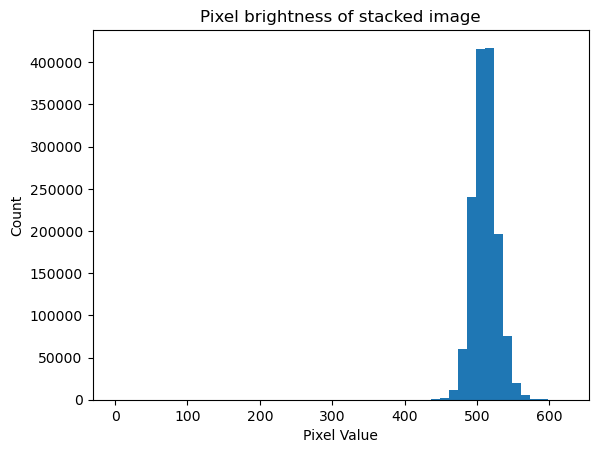

In [64]:
plt.hist(fits_combined.ravel(), bins=50)

plt.xlabel("Pixel Value")
plt.ylabel("Count")
plt.title("Pixel brightness of stacked image")

plt.show()

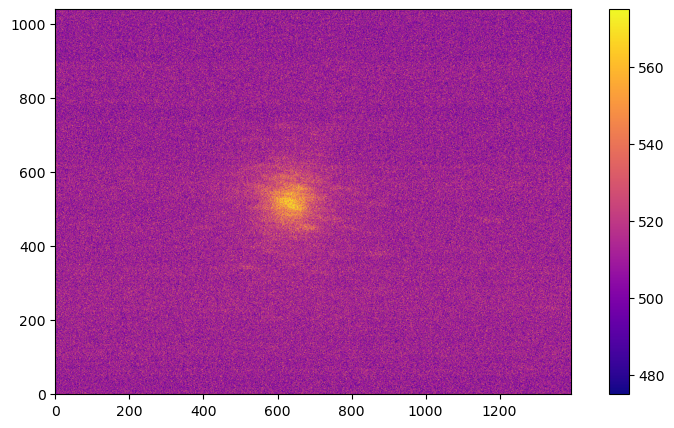

In [73]:
plt.figure(figsize = (10,5))
plt.imshow(fits_combined, origin='lower', vmin=475, vmax=575, cmap='plasma')
plt.colorbar()
plt.show()

There is only one image being plotted, as opposed to several different images. The center "bright spot" is substantially brighter.